# Federated Learning with Sparse CIFAR-10 (Flower Simulation)

This notebook demonstrates a **single-machine federated learning prototype** using the [Flower](https://flower.ai/) framework, built on top of the sparse CIFAR-10 classification task from the FL4HMA repository.

**What we'll cover:**
1. Loading and exploring the CIFAR-10 dataset
2. Defining the sparse CNN model
3. Partitioning data across simulated FL clients (IID and non-IID)
4. Defining the Flower client and server strategy
5. Running a federated simulation with `fl.simulation.start_simulation()`
6. Visualising training metrics across rounds
7. Evaluating the global model on the test set
8. Comparing federated vs. centralised training

## 1. Install and Import Dependencies

In [3]:
# Install Flower if needed (uncomment if not already installed)
# !pip install "flwr[simulation]>=1.5" torch torchvision matplotlib numpy

In [4]:
import sys, os
from collections import OrderedDict
from typing import Dict, List, Optional, Tuple

import flwr as fl
from flwr.client import NumPyClient
from flwr.common import Context
from flwr.server.strategy import FedAvg
from flwr.simulation import start_simulation

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Make sure the repo root is on the path so we can reference data/
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../src"))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Flower {fl.__version__} | PyTorch {torch.__version__} | Device: {DEVICE}")

2026-03-18 06:07:38,843	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /users/marr

Flower 1.23.0 | PyTorch 2.8.0+cu128 | Device: cuda


## 2. Load and Explore CIFAR-10 Data

In [5]:
DATA_DIR = "../data"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
full_test  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

CLASSES = full_train.classes
print(f"Training set : {len(full_train)} images")
print(f"Test set     : {len(full_test)} images")
print(f"Image shape  : {full_train[0][0].shape}")
print(f"Classes      : {CLASSES}")

# Class distribution
targets = np.array(full_train.targets)
for c in range(10):
    print(f"  {CLASSES[c]:>10s}: {(targets == c).sum()}")

Training set : 50000 images
Test set     : 10000 images
Image shape  : torch.Size([3, 32, 32])
Classes      : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    airplane: 5000
  automobile: 5000
        bird: 5000
         cat: 5000
        deer: 5000
         dog: 5000
        frog: 5000
       horse: 5000
        ship: 5000
       truck: 5000


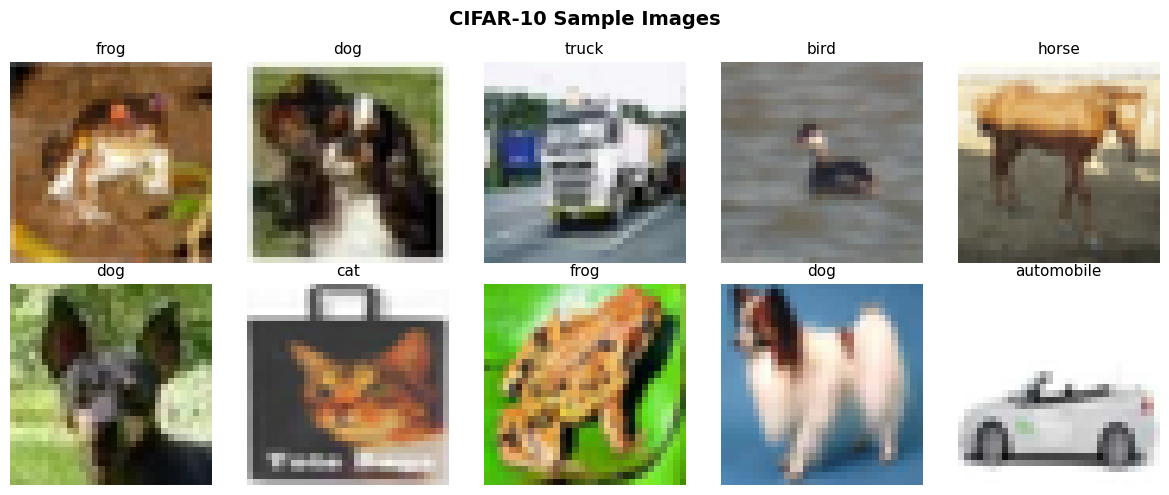

In [6]:
# Show a grid of sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = full_train[i * 500]
    img_np = img.permute(1, 2, 0).numpy() * 0.5 + 0.5  # denormalise
    ax.imshow(img_np)
    ax.set_title(CLASSES[label], fontsize=11)
    ax.axis("off")
plt.suptitle("CIFAR-10 Sample Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Define the Sparse CNN Model

We reuse the **VanillaCNN** architecture from the repository's `sparse_cifar10_example.py`:
- 3 convolutional layers (32 → 64 → 128 filters)
- Max-pooling after each conv block
- 2 fully-connected layers with dropout
- Compatible with Flower's parameter serialisation via `state_dict` ↔ NumPy

In [7]:
class VanillaCNN(nn.Module):
    """Simple CNN for CIFAR-10 classification."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

model = VanillaCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"VanillaCNN — {total_params:,} parameters")
print(model)

VanillaCNN — 1,147,466 parameters
VanillaCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


## 4. Sparse Label Encoding & Parameter Utilities

In this FL scenario, each client only has labels for a **fraction** of its data (sparse supervision). We also define helpers to move model parameters between PyTorch and Flower's NumPy-based protocol.

In [8]:
class SparseCIFAR10Dataset(Dataset):
    """CIFAR-10 subset with sparse labels (unlabelled samples get target = -1)."""
    def __init__(self, subset: Subset, sparsity: float = 0.1, seed: int = 42):
        self.subset = subset
        self.sparsity = sparsity
        rng = np.random.RandomState(seed)
        self.sparse_mask = rng.random(len(subset)) < sparsity

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        is_labeled = bool(self.sparse_mask[idx])
        sparse_label = label if is_labeled else -1
        return image, sparse_label, is_labeled


def get_parameters(model: nn.Module) -> List[np.ndarray]:
    """Extract model parameters as a list of NumPy arrays."""
    return [val.cpu().numpy() for _, val in model.state_dict().items()]


def set_parameters(model: nn.Module, parameters: List[np.ndarray]) -> None:
    """Load parameters into a model from NumPy arrays."""
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)


# Quick sanity check: round-trip parameters
params = get_parameters(model)
print(f"Number of parameter tensors: {len(params)}")
print(f"Shapes: {[p.shape for p in params]}")

model2 = VanillaCNN().to(DEVICE)
set_parameters(model2, params)
for (k, p1), (_, p2) in zip(model.state_dict().items(), model2.state_dict().items()):
    assert torch.equal(p1, p2), f"Mismatch in {k}"
print("✓ Parameter round-trip verified")

Number of parameter tensors: 10
Shapes: [(32, 3, 3, 3), (32,), (64, 32, 3, 3), (64,), (128, 64, 3, 3), (128,), (512, 2048), (512,), (10, 512), (10,)]
✓ Parameter round-trip verified


## 5. Create Federated Data Partitions (IID Split)

We split the 50 000 training images into `NUM_CLIENTS` equal-sized partitions. Each client then wraps its partition in a `SparseCIFAR10Dataset` so only `SPARSITY` fraction of labels are visible — mimicking scenarios where field measurements are expensive.

In [9]:
# ----- Configuration -----
NUM_CLIENTS  = 5
NUM_ROUNDS   = 10
LOCAL_EPOCHS = 2
SPARSITY     = 0.10   # 10 % of labels visible per client
BATCH_SIZE   = 32
LR           = 0.001

np.random.seed(42)
torch.manual_seed(42)

# IID partitioning
indices = np.random.permutation(len(full_train))
splits  = np.array_split(indices, NUM_CLIENTS)

client_datasets = []
for cid, idx in enumerate(splits):
    subset = Subset(full_train, idx.tolist())
    ds = SparseCIFAR10Dataset(subset, sparsity=SPARSITY, seed=42 + cid)
    client_datasets.append(ds)

# Fully-labelled test set
test_subset  = Subset(full_test, list(range(len(full_test))))
test_dataset = SparseCIFAR10Dataset(test_subset, sparsity=1.0, seed=0)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Print partition summary
for i, ds in enumerate(client_datasets):
    labeled = int(ds.sparse_mask.sum())
    print(f"  Client {i}: {len(ds):>6} samples, {labeled:>5} labelled ({labeled/len(ds)*100:.1f}%)")
print(f"\n  Test set : {len(test_dataset)} samples (100% labelled)")

  Client 0:  10000 samples,  1031 labelled (10.3%)
  Client 1:  10000 samples,   985 labelled (9.8%)
  Client 2:  10000 samples,   963 labelled (9.6%)
  Client 3:  10000 samples,  1020 labelled (10.2%)
  Client 4:  10000 samples,  1037 labelled (10.4%)

  Test set : 10000 samples (100% labelled)


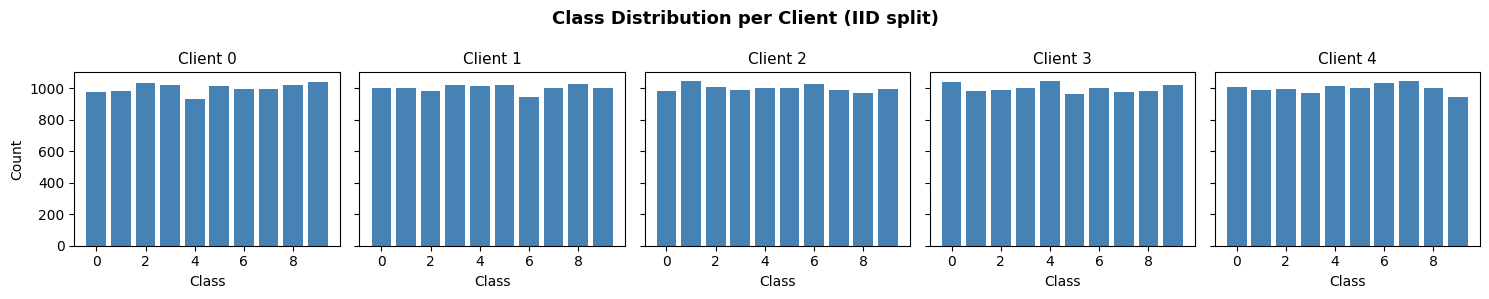

In [10]:
# Visualise class distribution per client partition
fig, axes = plt.subplots(1, NUM_CLIENTS, figsize=(3 * NUM_CLIENTS, 3), sharey=True)
for cid in range(NUM_CLIENTS):
    subset_targets = [full_train.targets[j] for j in splits[cid]]
    axes[cid].bar(range(10), np.bincount(subset_targets, minlength=10), color="steelblue")
    axes[cid].set_title(f"Client {cid}", fontsize=11)
    axes[cid].set_xlabel("Class")
    if cid == 0:
        axes[cid].set_ylabel("Count")
plt.suptitle("Class Distribution per Client (IID split)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Define the Flower Client Class

Each Flower client:
- Receives global model parameters at the start of each round
- Trains locally for `LOCAL_EPOCHS` on its partition (using only labelled samples)
- Returns the updated parameters, sample count, and training loss

In [14]:
def _get_device():
    """Detect device dynamically — works inside Ray workers where CUDA may be masked."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_on_client(model, loader, epochs=1, lr=0.001):
    """Local training loop — only uses labelled samples."""
    device = _get_device()
    model.to(device)
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss, n_batches = 0.0, 0
    for _ in range(epochs):
        for data, targets, is_labeled in loader:
            data, targets = data.to(device), targets.to(device)
            is_labeled = is_labeled.to(device)
            mask = is_labeled & (targets != -1)
            if mask.sum() == 0:
                continue
            optimizer.zero_grad()
            loss = criterion(model(data[mask]), targets[mask])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(1, n_batches)


def evaluate(model, loader):
    """Evaluate accuracy on a DataLoader."""
    device = _get_device()
    model.to(device)
    model.eval()
    correct = total = 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for data, targets, _ in loader:
            data, targets = data.to(device), targets.to(device)
            out = model(data)
            loss_sum += criterion(out, targets).item() * targets.size(0)
            correct += (out.argmax(1) == targets).sum().item()
            total += targets.size(0)
    return loss_sum / total, correct, total


class CifarFlowerClient(NumPyClient):
    """Flower client wrapping local sparse CIFAR-10 training."""
    def __init__(self, train_ds, local_epochs, batch_size, lr):
        self.loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        self.local_epochs = local_epochs
        self.lr = lr
        self.device = _get_device()
        self.model = VanillaCNN().to(self.device)
        self.num_examples = len(train_ds)

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.to(self.device)
        loss = train_on_client(self.model, self.loader,
                               epochs=self.local_epochs, lr=self.lr)
        return get_parameters(self.model), self.num_examples, {"train_loss": loss}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.to(self.device)
        loss, correct, total = evaluate(self.model, self.loader)
        return loss, total, {"accuracy": correct / total}


def client_fn(context: Context):
    """Factory function that Flower calls to create a client."""
    cid = int(context.node_config["partition-id"])
    return CifarFlowerClient(
        train_ds=client_datasets[cid],
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
    ).to_client()

print("✓ Client class and factory function defined")

✓ Client class and factory function defined


## 7. Define the Flower Server Strategy

We use **FedAvg** (Federated Averaging) — the canonical FL aggregation algorithm:
- All clients participate every round (`fraction_fit=1.0`)
- Server-side evaluation on the centralised test set after each round
- Initial parameters from a randomly initialised model

In [15]:
# We use a mutable dict to capture the final parameters during server-side evaluation
final_params_store = {}

def get_evaluate_fn(test_loader):
    """Return a server-side (centralised) evaluation function."""
    def evaluate_fn(server_round, parameters, config):
        m = VanillaCNN().to(DEVICE)
        set_parameters(m, parameters)
        loss, correct, total = evaluate(m, test_loader)
        acc = correct / total
        print(f"  [Server] Round {server_round}: loss={loss:.4f}, acc={acc:.4f}")
        # Store the latest parameters so we can use them after simulation
        final_params_store["params"] = parameters
        return loss, {"accuracy": acc}
    return evaluate_fn


initial_params = fl.common.ndarrays_to_parameters(get_parameters(VanillaCNN()))

strategy = FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,          # skip distributed eval — use centralised
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=get_evaluate_fn(test_loader),
    initial_parameters=initial_params,
)
print(f"✓ FedAvg strategy created (fraction_fit=1.0, {NUM_CLIENTS} clients)")

✓ FedAvg strategy created (fraction_fit=1.0, 5 clients)


## 8. Run Federated Learning Simulation

Flower's `start_simulation()` spawns virtual clients on a single machine using [Ray](https://www.ray.io/). Each round:
1. Server sends global model to all selected clients
2. Clients train locally on their sparse data
3. Server aggregates updates via FedAvg
4. Server evaluates the new global model on the test set

In [16]:
%%time
# Allocate a fraction of the GPU to each client so they can use CUDA
gpu_per_client = 1.0 / NUM_CLIENTS if torch.cuda.is_available() else 0.0

history = start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": gpu_per_client},
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-03-18 06:12:53,670	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 48.0, 'memory': 356522442138.0, 'accelerator_type:A2': 1.0, 'object_store_memory': 157081046630.0, 'GPU': 1.0, 'node:10.27.3.178': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.2}
INFO :    

  [Server] Round 0: loss=2.3034, acc=0.0997


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      fit progress: (1, 2.295845584487915, {'accuracy': 0.1}, 22.87107198126614)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


  [Server] Round 1: loss=2.2958, acc=0.1000


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      fit progress: (2, 2.027559087753296, {'accuracy': 0.2819}, 36.327300443314016)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


...

  [Server] Round 8: loss=1.3117, acc=0.5246


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      fit progress: (9, 1.2803231628417968, {'accuracy': 0.5425}, 120.79433167446405)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


  [Server] Round 9: loss=1.2803, acc=0.5425


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      fit progress: (10, 1.261550449180603, {'accuracy': 0.5545}, 133.03196366969496)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 133.03s
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.3034265933990477
INFO :      		round 1: 2.295845584487915
INFO :      		round 2: 2.027559087753296
INFO :      		round 3: 1.6761745443344116
INFO :      		round 4: 1.5442822816848756
INFO :      		round 5: 1.4567812885284424
INFO :      		round 6: 1.391981785964966
INFO :      		round 7: 1.3294834442138672
INFO :      		round 8: 1.3116867416381837
INFO :      		round 9: 1.2803231628417968
INFO :      		round 10: 1.261550449180603
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.0997),
INFO :      	              (1, 0.1),
INFO :      	              (2, 0.2819),
INFO :      	              (

  [Server] Round 10: loss=1.2616, acc=0.5545
CPU times: user 59.3 s, sys: 5.87 s, total: 1min 5s
Wall time: 2min 22s


## 9. Visualise Training Metrics Across Rounds

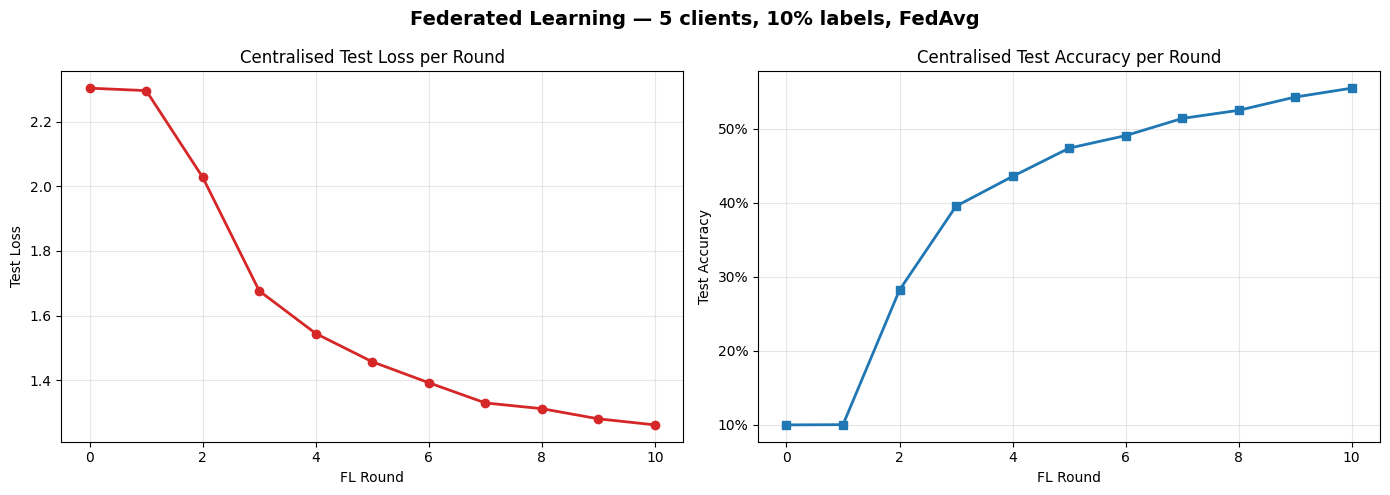


Final test accuracy: 0.5545


In [17]:
# Extract metrics from Flower History
fl_rounds  = [r for r, _ in history.losses_centralized]
fl_losses  = [l for _, l in history.losses_centralized]
fl_accs    = [a for _, a in history.metrics_centralized.get("accuracy", [])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(fl_rounds, fl_losses, "o-", color="tab:red", linewidth=2, markersize=6)
ax1.set_xlabel("FL Round")
ax1.set_ylabel("Test Loss")
ax1.set_title("Centralised Test Loss per Round")
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(fl_rounds, fl_accs, "s-", color="tab:blue", linewidth=2, markersize=6)
ax2.set_xlabel("FL Round")
ax2.set_ylabel("Test Accuracy")
ax2.set_title("Centralised Test Accuracy per Round")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f"Federated Learning — {NUM_CLIENTS} clients, {SPARSITY*100:.0f}% labels, FedAvg",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {fl_accs[-1]:.4f}")

## 10. Evaluate the Global Model on the Test Set

Load the final global model from the last FL round and compute per-class accuracy, a confusion matrix, and example predictions.

In [18]:
# Retrieve the final global parameters saved during the last server-side evaluation
final_model = VanillaCNN().to(DEVICE)
set_parameters(final_model, final_params_store["params"])

# Full test evaluation
final_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for data, targets, _ in test_loader:
        data = data.to(DEVICE)
        preds = final_model(data).argmax(1).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds   = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()
overall_acc = (all_preds == all_targets).mean()
print(f"Overall test accuracy: {overall_acc:.4f}\n")

# Per-class accuracy
print(f"{'Class':>12s}  Accuracy")
print("-" * 25)
for c in range(10):
    mask = all_targets == c
    class_acc = (all_preds[mask] == c).mean()
    print(f"{CLASSES[c]:>12s}  {class_acc:.4f}")

Overall test accuracy: 0.5545

       Class  Accuracy
-------------------------
    airplane  0.5600
  automobile  0.7140
        bird  0.3870
         cat  0.3480
        deer  0.3340
         dog  0.4550
        frog  0.7220
       horse  0.6690
        ship  0.6970
       truck  0.6590


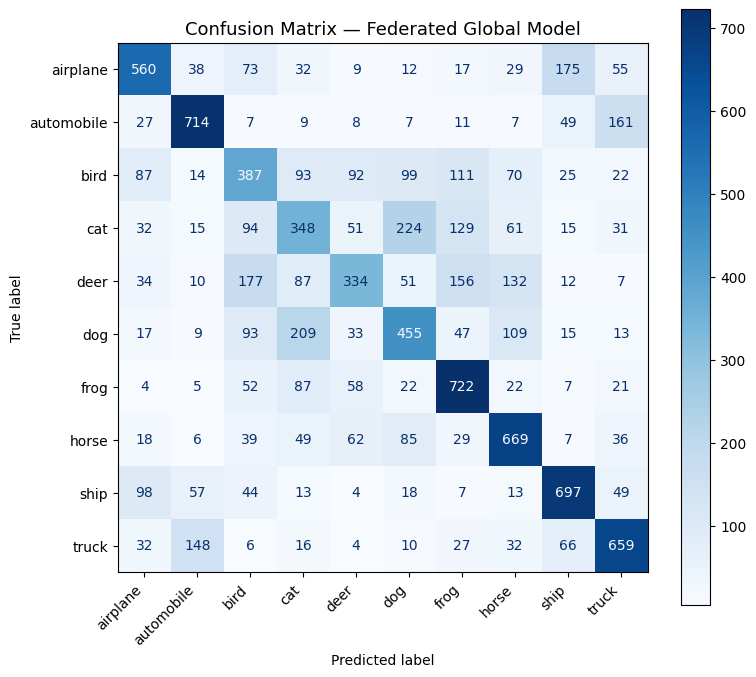

In [19]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — Federated Global Model", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

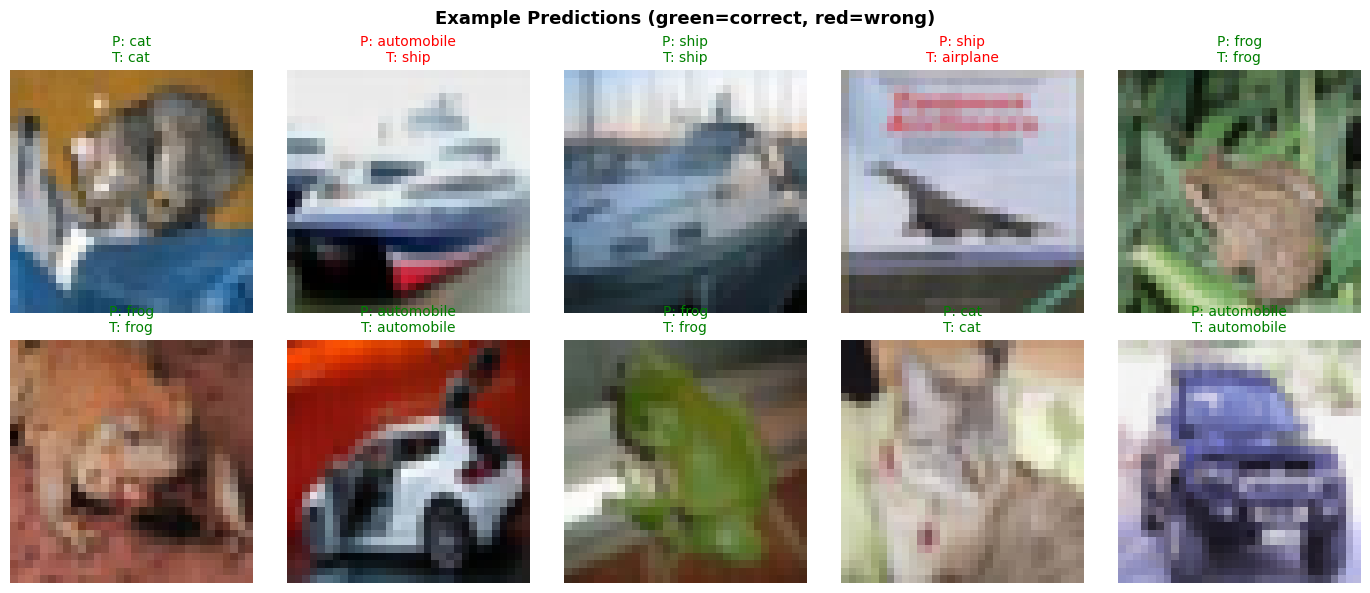

In [20]:
# Show example predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
test_imgs = [full_test[i] for i in range(10)]
for i, ax in enumerate(axes.flat):
    img, true_label = test_imgs[i]
    img_np = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
    pred_label = all_preds[i]
    colour = "green" if pred_label == true_label else "red"
    ax.imshow(img_np)
    ax.set_title(f"P: {CLASSES[pred_label]}\nT: {CLASSES[true_label]}",
                 fontsize=10, color=colour)
    ax.axis("off")
plt.suptitle("Example Predictions (green=correct, red=wrong)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Compare Federated vs. Centralised Sparse Training

For a fair comparison, we train the same VanillaCNN in a **centralised** setting using the same total amount of labelled data (all clients' labels pooled) for the same total number of gradient steps (`NUM_ROUNDS × LOCAL_EPOCHS` epochs).

In [21]:
%%time
# Centralised training with the same sparse labels
central_epochs = NUM_ROUNDS * LOCAL_EPOCHS  # same total training effort

# Pool all client data into one dataset
central_ds = SparseCIFAR10Dataset(
    Subset(full_train, list(range(len(full_train)))),
    sparsity=SPARSITY, seed=42,
)
central_loader = DataLoader(central_ds, batch_size=BATCH_SIZE, shuffle=True)

central_model = VanillaCNN().to(DEVICE)
optimizer = optim.Adam(central_model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

central_losses = []
central_accs   = []

for epoch in range(central_epochs):
    central_model.train()
    epoch_loss, n = 0.0, 0
    for data, targets, is_labeled in central_loader:
        data, targets = data.to(DEVICE), targets.to(DEVICE)
        is_labeled = is_labeled.to(DEVICE)
        mask = is_labeled & (targets != -1)
        if mask.sum() == 0:
            continue
        optimizer.zero_grad()
        loss = criterion(central_model(data[mask]), targets[mask])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n += 1
    central_losses.append(epoch_loss / max(1, n))

    # Evaluate every epoch
    loss_e, correct_e, total_e = evaluate(central_model, test_loader)
    central_accs.append(correct_e / total_e)
    print(f"  Epoch {epoch+1}/{central_epochs}: loss={central_losses[-1]:.4f}, acc={central_accs[-1]:.4f}")

  Epoch 1/20: loss=2.0158, acc=0.3369
  Epoch 2/20: loss=1.6839, acc=0.4453
  Epoch 3/20: loss=1.5171, acc=0.4403
  Epoch 4/20: loss=1.3881, acc=0.4955
  Epoch 5/20: loss=1.2847, acc=0.5085
  Epoch 6/20: loss=1.1950, acc=0.5178
  Epoch 7/20: loss=1.1165, acc=0.5270
  Epoch 8/20: loss=0.9931, acc=0.5312
  Epoch 9/20: loss=0.8743, acc=0.5316
  Epoch 10/20: loss=0.7584, acc=0.5434
  Epoch 11/20: loss=0.7145, acc=0.5457
  Epoch 12/20: loss=0.6265, acc=0.5450
  Epoch 13/20: loss=0.5605, acc=0.5499
  Epoch 14/20: loss=0.4876, acc=0.5414
  Epoch 15/20: loss=0.4418, acc=0.5433
  Epoch 16/20: loss=0.4481, acc=0.5484
  Epoch 17/20: loss=0.3834, acc=0.5303
  Epoch 18/20: loss=0.3327, acc=0.5290
  Epoch 19/20: loss=0.3468, acc=0.5533
  Epoch 20/20: loss=0.3403, acc=0.5433
CPU times: user 5min 1s, sys: 1.24 s, total: 5min 2s
Wall time: 4min 47s


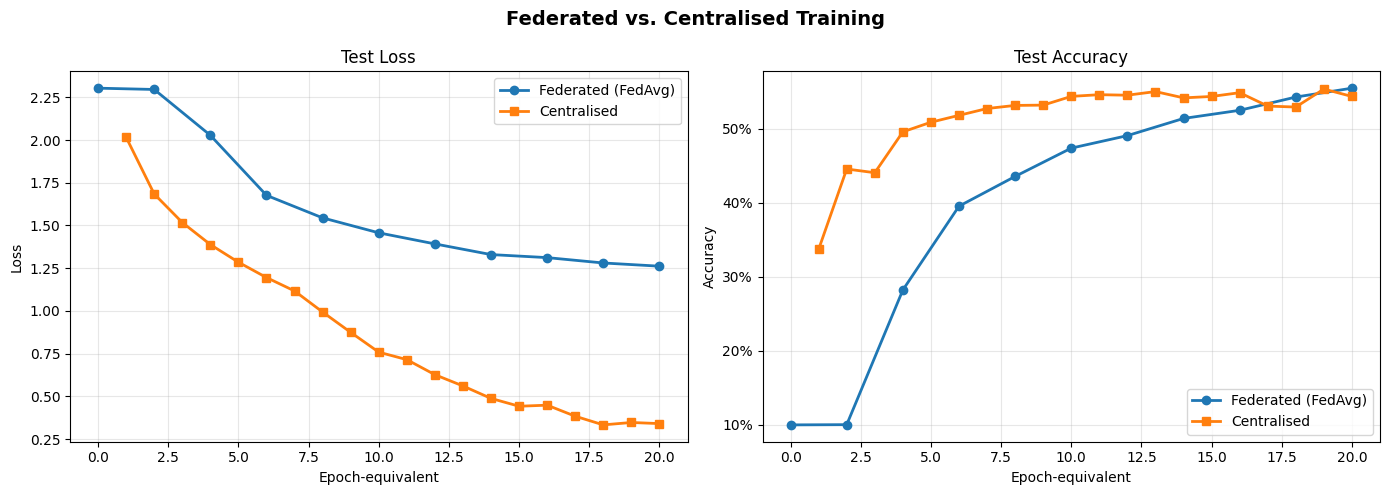


                           Federated   Centralised
----------------------------------------------------
   Final test accuracy        0.5545        0.5433
       Final test loss        1.2616        0.3403
          Total epochs            20            20
               Clients             5             1
              Sparsity           10%           10%


In [22]:
# Compare learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Map FL rounds → equivalent epoch numbers for comparison
fl_epoch_equiv = [r * LOCAL_EPOCHS for r in fl_rounds]

ax1.plot(fl_epoch_equiv, fl_losses, "o-", label="Federated (FedAvg)", linewidth=2)
ax1.plot(range(1, central_epochs + 1), central_losses, "s-", label="Centralised", linewidth=2)
ax1.set_xlabel("Epoch-equivalent")
ax1.set_ylabel("Loss")
ax1.set_title("Test Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(fl_epoch_equiv, fl_accs, "o-", label="Federated (FedAvg)", linewidth=2)
ax2.plot(range(1, central_epochs + 1), central_accs, "s-", label="Centralised", linewidth=2)
ax2.set_xlabel("Epoch-equivalent")
ax2.set_ylabel("Accuracy")
ax2.set_title("Test Accuracy")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Federated vs. Centralised Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'':>22s}  {'Federated':>12s}  {'Centralised':>12s}")
print("-" * 52)
print(f"{'Final test accuracy':>22s}  {fl_accs[-1]:>12.4f}  {central_accs[-1]:>12.4f}")
print(f"{'Final test loss':>22s}  {fl_losses[-1]:>12.4f}  {central_losses[-1]:>12.4f}")
print(f"{'Total epochs':>22s}  {NUM_ROUNDS * LOCAL_EPOCHS:>12d}  {central_epochs:>12d}")
print(f"{'Clients':>22s}  {NUM_CLIENTS:>12d}  {'1':>12s}")
print(f"{'Sparsity':>22s}  {SPARSITY*100:>11.0f}%  {SPARSITY*100:>11.0f}%")

## Summary

This notebook demonstrated a **single-machine federated learning prototype** using Flower:

| Aspect | Detail |
|--------|--------|
| **Framework** | Flower (`flwr`) with `start_simulation()` |
| **Task** | Sparse CIFAR-10 classification (only 10% labels visible per client) |
| **Model** | VanillaCNN (~1.1M params) |
| **Aggregation** | FedAvg (Federated Averaging) |
| **Clients** | 5 simulated clients (IID split) |
| **Rounds** | 10 FL rounds × 2 local epochs each |

**Key takeaways:**
- Federated learning with sparse labels is viable and achieves reasonable accuracy
- The FL setup adds communication overhead but keeps data decentralised
- Centralised training with the same label budget serves as an upper-bound baseline
- Flower makes it straightforward to prototype FL experiments on a single machine